# scRNA-seq PBMC Analysis
**Dataset:** 10x Genomics PBMC 3k  
**Stack:** Scanpy + AnnData  
**Pipeline:** QC → Preprocessing → Clustering → Annotation → Differential Expression

## 1. Setup

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white', frameon=False)

print(f'Scanpy version: {sc.__version__}')

Scanpy version: 1.12.1


## 2. Load Data

In [2]:
# Download and load the 10x PBMC 3k dataset (cached after first download)
adata = sc.datasets.pbmc3k()
print(adata)
print(f'\n{adata.n_obs} cells × {adata.n_vars} genes')

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'

2700 cells × 32738 genes


## 3. Quality Control

In [3]:
# Flag mitochondrial genes (marker of cell stress / dying cells)
adata.var['mt'] = adata.var_names.str.startswith('MT-')

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=['mt'],
    percent_top=None,
    log1p=False,
    inplace=True
)

adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt
count,2700.000000,2700.000000,2700.000000
mean,846.994074,2366.900391,2.215132
std,282.104964,1094.262085,1.165438
min,212.000000,548.000000,0.000000
25%,690.000000,1757.750000,1.536238
50%,817.000000,2197.000000,2.029639
75%,953.250000,2763.000000,2.640218
max,3422.000000,15844.000000,22.569027


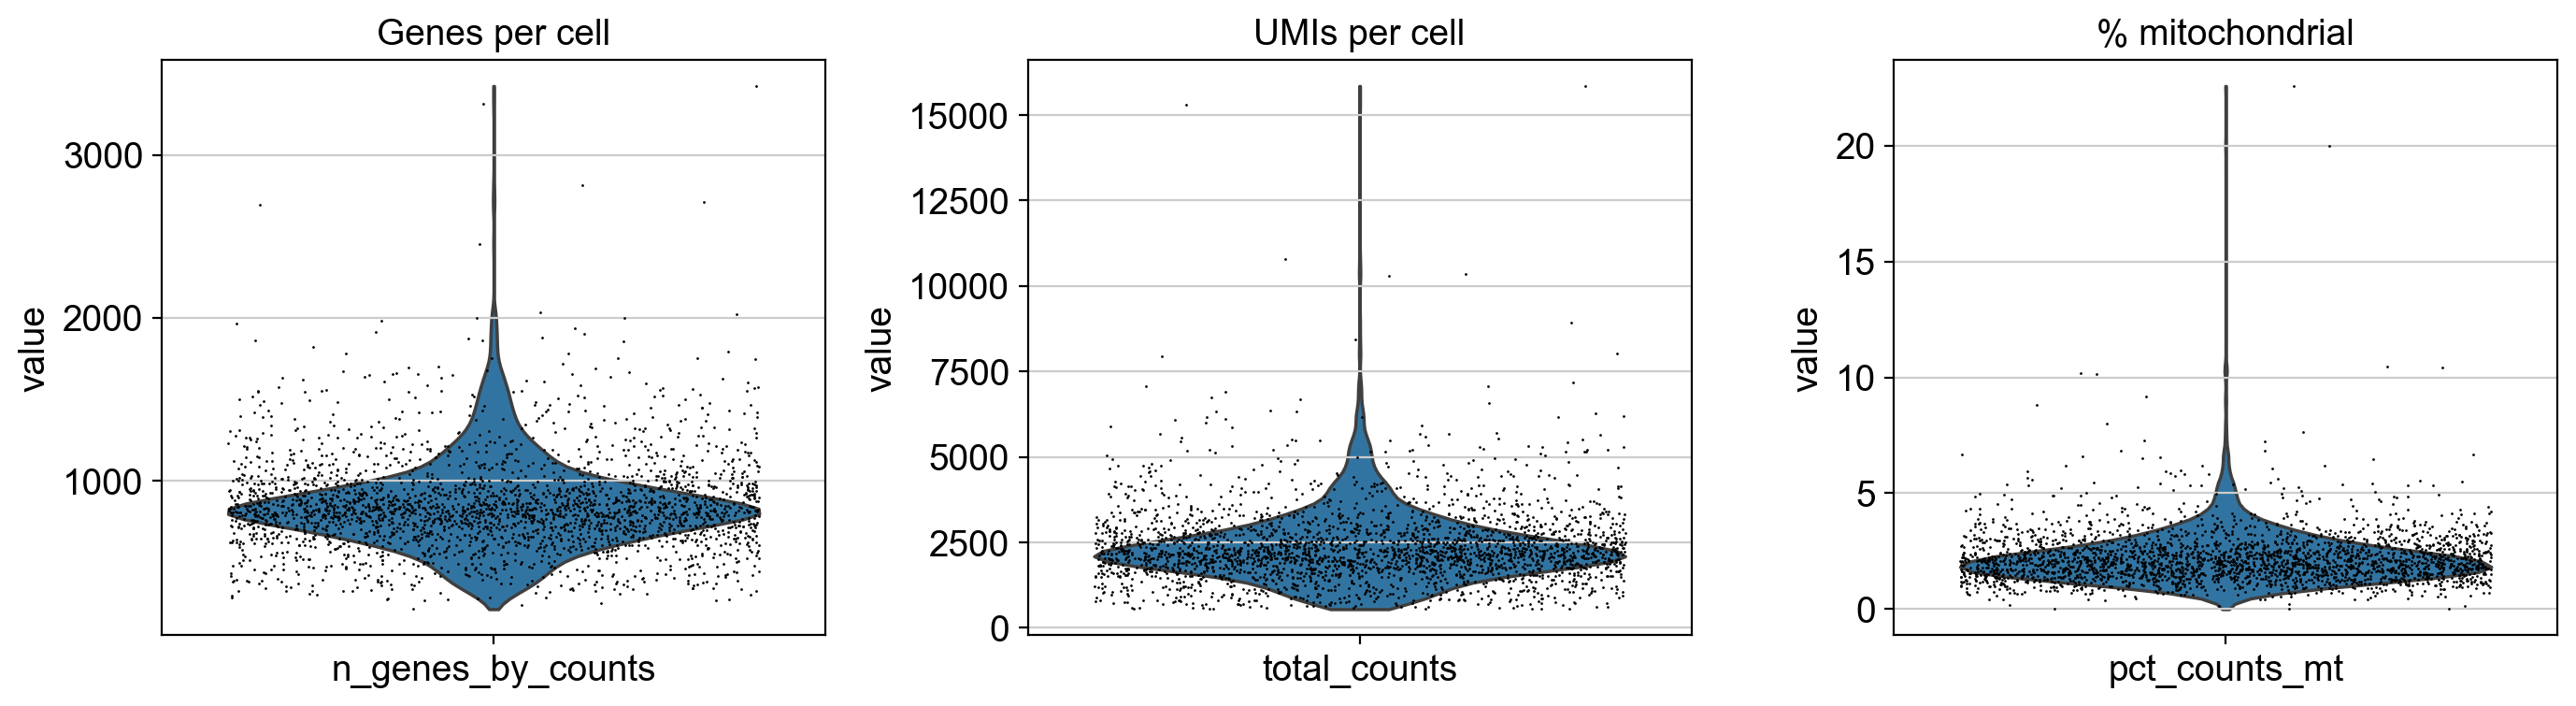

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sc.pl.violin(adata, 'n_genes_by_counts', jitter=0.4, ax=axes[0], show=False)
axes[0].set_title('Genes per cell')

sc.pl.violin(adata, 'total_counts', jitter=0.4, ax=axes[1], show=False)
axes[1].set_title('UMIs per cell')

sc.pl.violin(adata, 'pct_counts_mt', jitter=0.4, ax=axes[2], show=False)
axes[2].set_title('% mitochondrial')

plt.tight_layout()
plt.show()

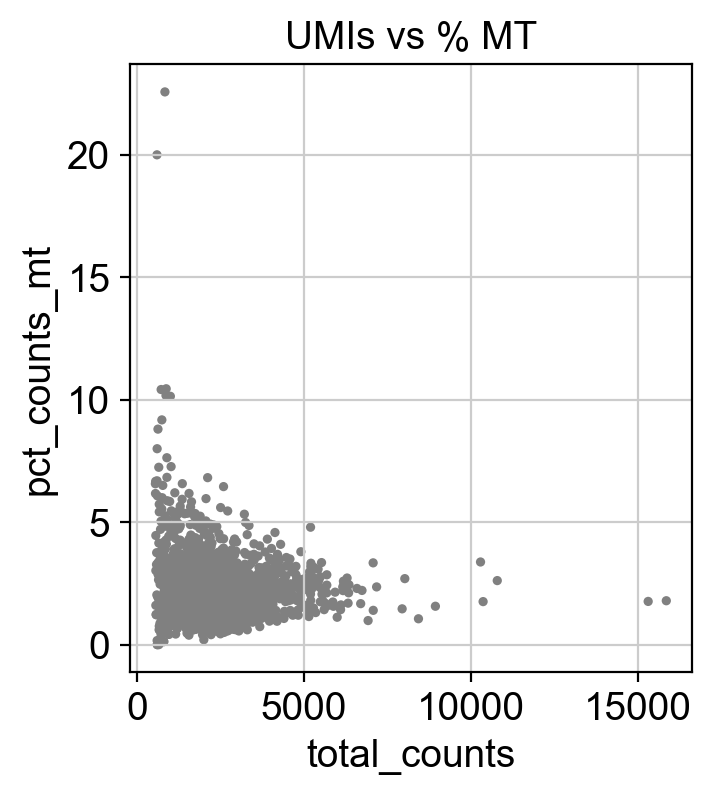

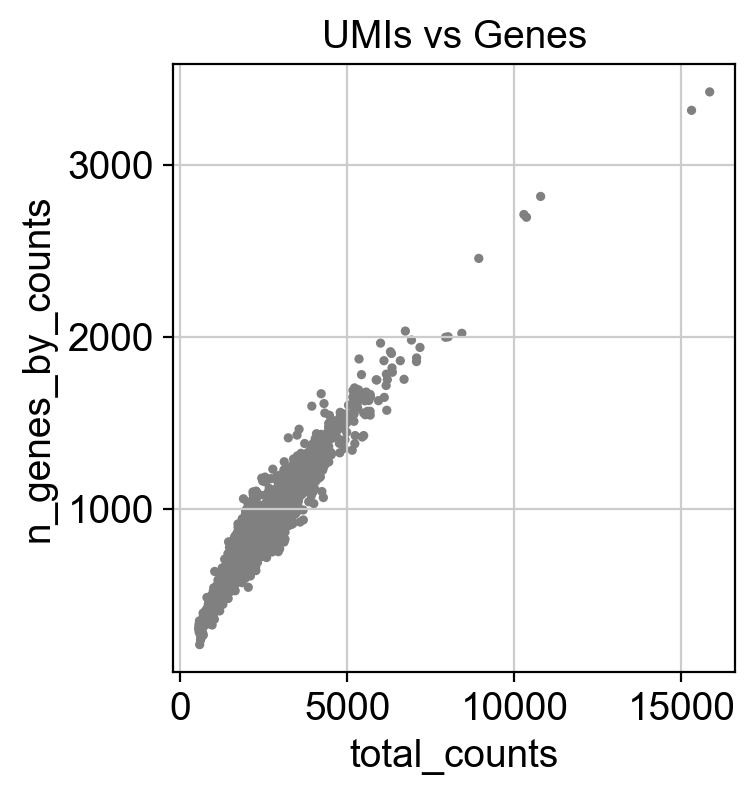

In [5]:
sc.pl.scatter(adata, x='total_counts', y='pct_counts_mt', title='UMIs vs % MT')
sc.pl.scatter(adata, x='total_counts', y='n_genes_by_counts', title='UMIs vs Genes')

In [6]:
# Filter cells: remove low-quality cells and likely doublets
print(f'Before filtering: {adata.n_obs} cells')

sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)

adata = adata[adata.obs.n_genes_by_counts < 2500, :]
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f'After filtering:  {adata.n_obs} cells × {adata.n_vars} genes')

Before filtering: 2700 cells
After filtering:  2638 cells × 13714 genes


## 4. Normalization & Feature Selection

Highly variable genes: 1838


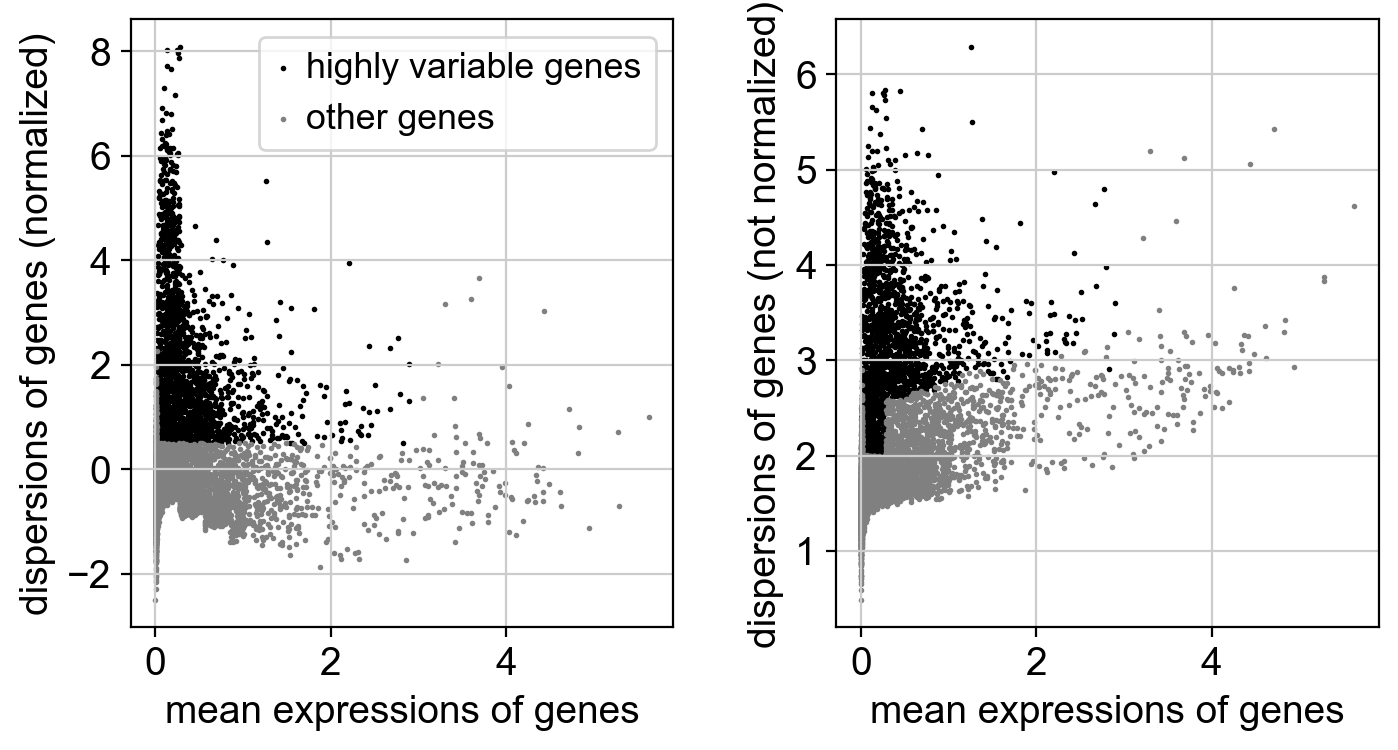

In [7]:
# Store raw counts for DE testing later
adata.layers['counts'] = adata.X.copy()

# Normalize to 10,000 counts per cell, then log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Save log-normalized expression for later
adata.raw = adata

# Select highly variable genes
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f'Highly variable genes: {adata.var.highly_variable.sum()}')

sc.pl.highly_variable_genes(adata)

In [8]:
# Keep only HVGs, regress out confounders, scale
adata = adata[:, adata.var.highly_variable]

sc.pp.regress_out(adata, ['total_counts', 'pct_counts_mt'])
sc.pp.scale(adata, max_value=10)

## 5. Dimensionality Reduction

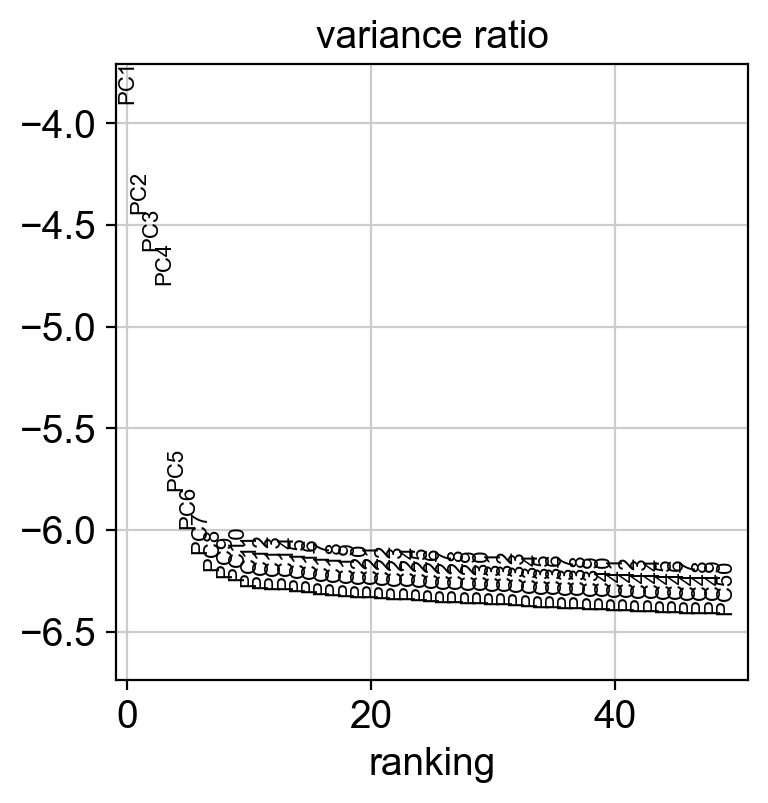

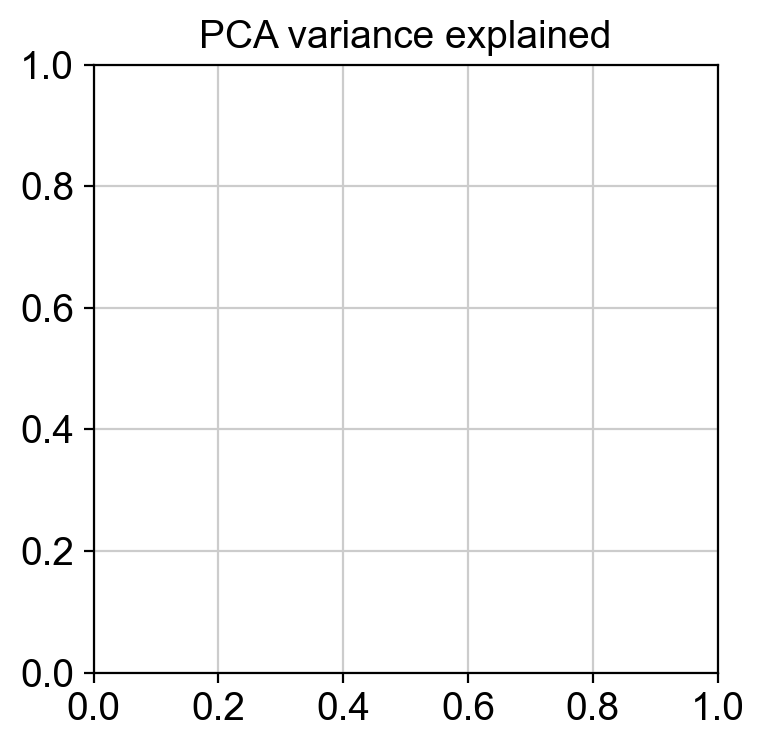

In [9]:
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)
plt.title('PCA variance explained')
plt.show()

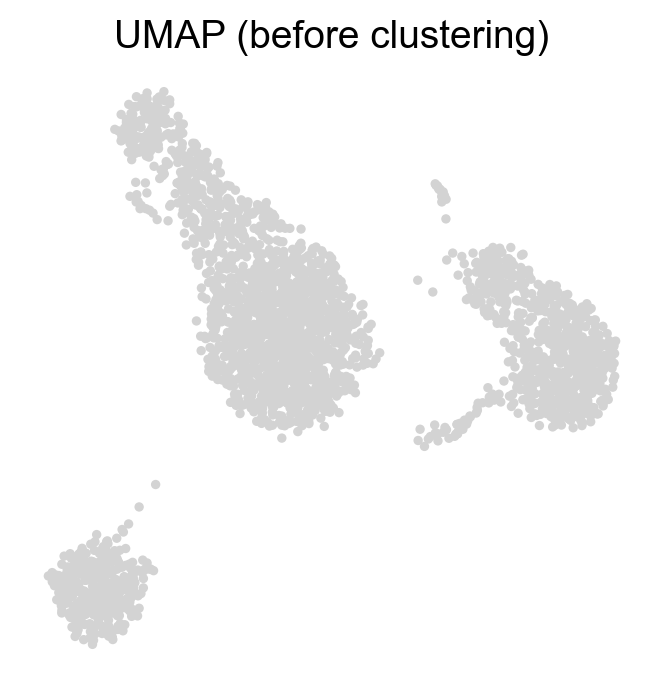

In [10]:
# Build neighborhood graph and compute UMAP
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, title='UMAP (before clustering)')

## 6. Clustering

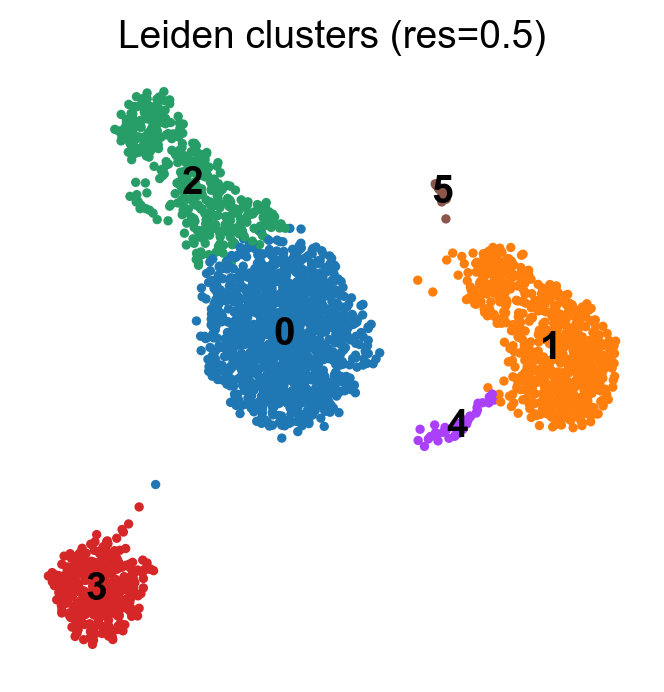

Number of clusters: 6
leiden
0    1202
1     636
2     410
3     341
4      36
5      13
Name: count, dtype: int64


In [11]:
# Leiden clustering (resolution controls granularity: higher = more clusters)
sc.tl.leiden(adata, resolution=0.5, random_state=42)

sc.pl.umap(adata, color='leiden', legend_loc='on data',
           title='Leiden clusters (res=0.5)', frameon=False)

print(f'Number of clusters: {adata.obs.leiden.nunique()}')
print(adata.obs.leiden.value_counts())

## 7. Cell Type Annotation

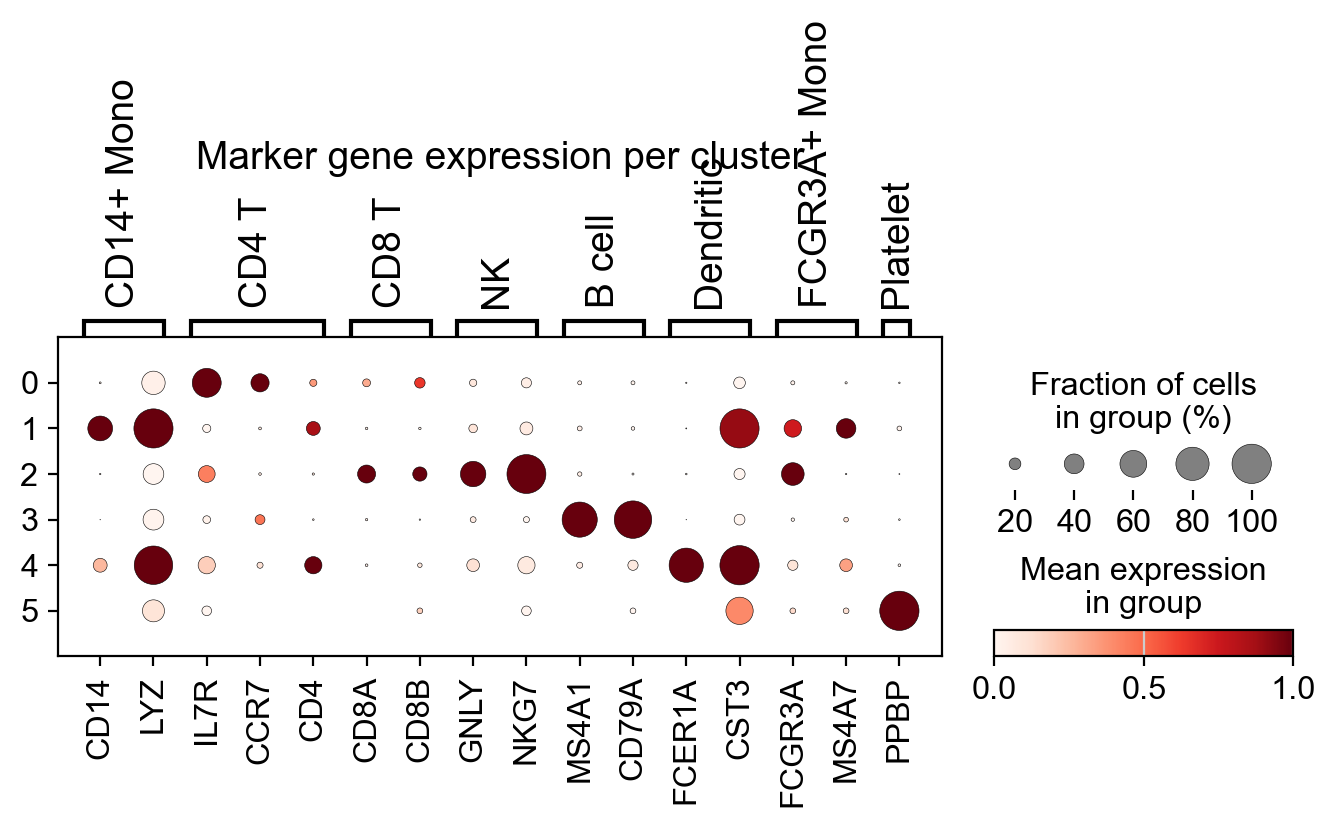

In [12]:
# Canonical PBMC marker genes
marker_genes = {
    'CD14+ Mono':    ['CD14', 'LYZ'],
    'CD4 T':         ['IL7R', 'CCR7', 'CD4'],
    'CD8 T':         ['CD8A', 'CD8B'],
    'NK':            ['GNLY', 'NKG7'],
    'B cell':        ['MS4A1', 'CD79A'],
    'Dendritic':     ['FCER1A', 'CST3'],
    'FCGR3A+ Mono':  ['FCGR3A', 'MS4A7'],
    'Platelet':      ['PPBP'],
}

sc.pl.dotplot(
    adata,
    marker_genes,
    groupby='leiden',
    standard_scale='var',
    title='Marker gene expression per cluster'
)

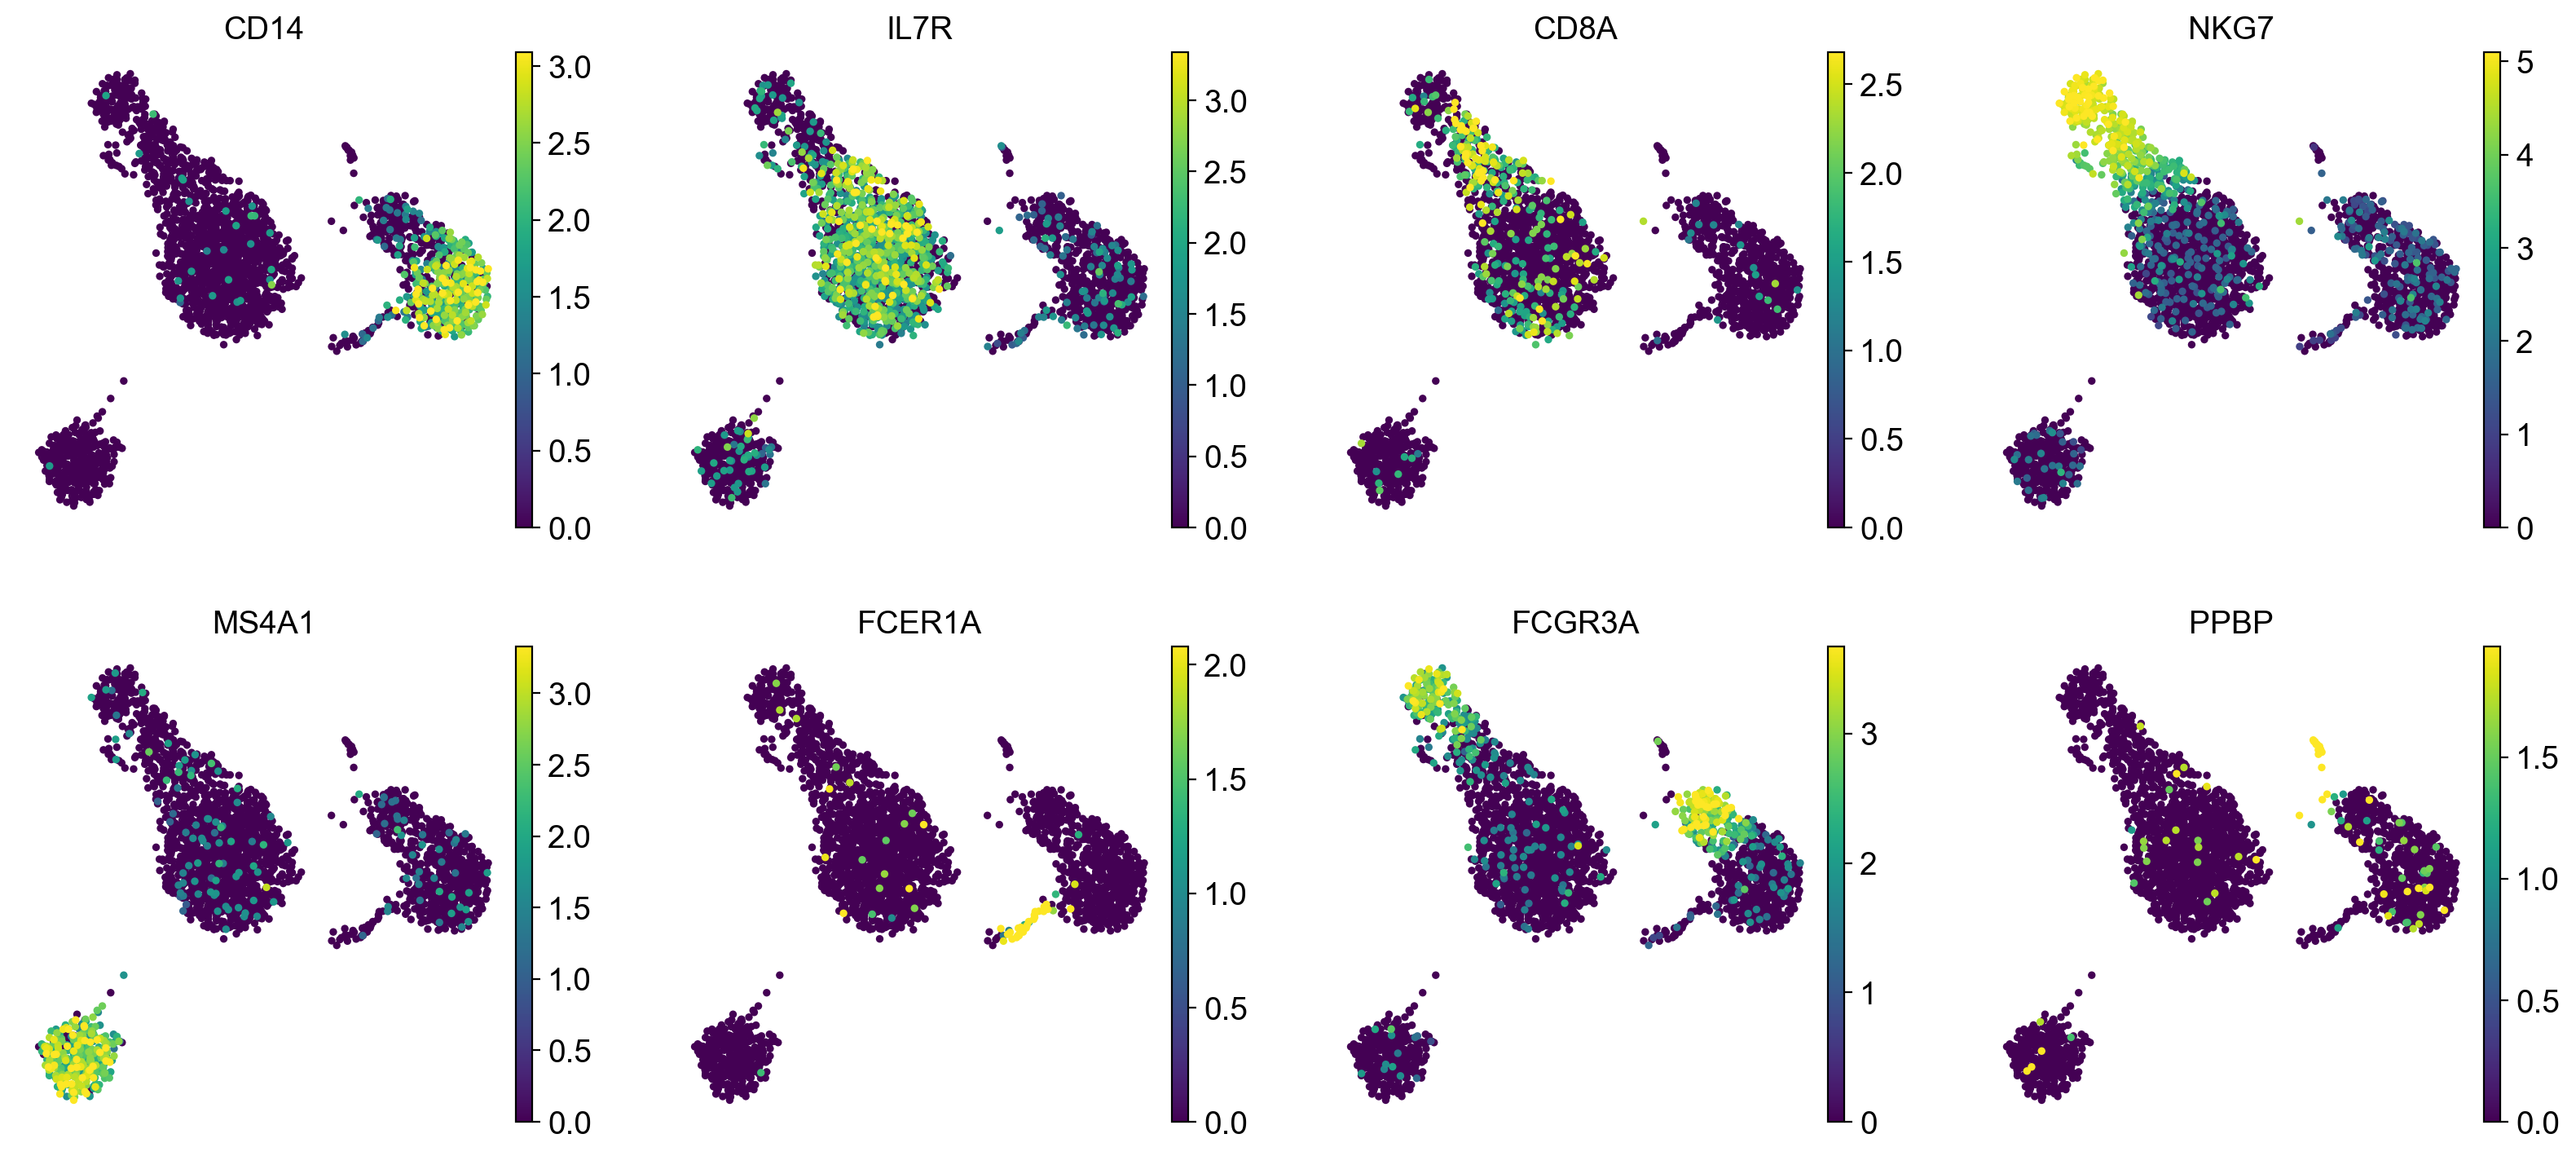

In [13]:
# Visualize individual markers on UMAP
top_markers = ['CD14', 'IL7R', 'CD8A', 'NKG7', 'MS4A1', 'FCER1A', 'FCGR3A', 'PPBP']
sc.pl.umap(adata, color=top_markers, ncols=4, use_raw=True, vmax='p99')

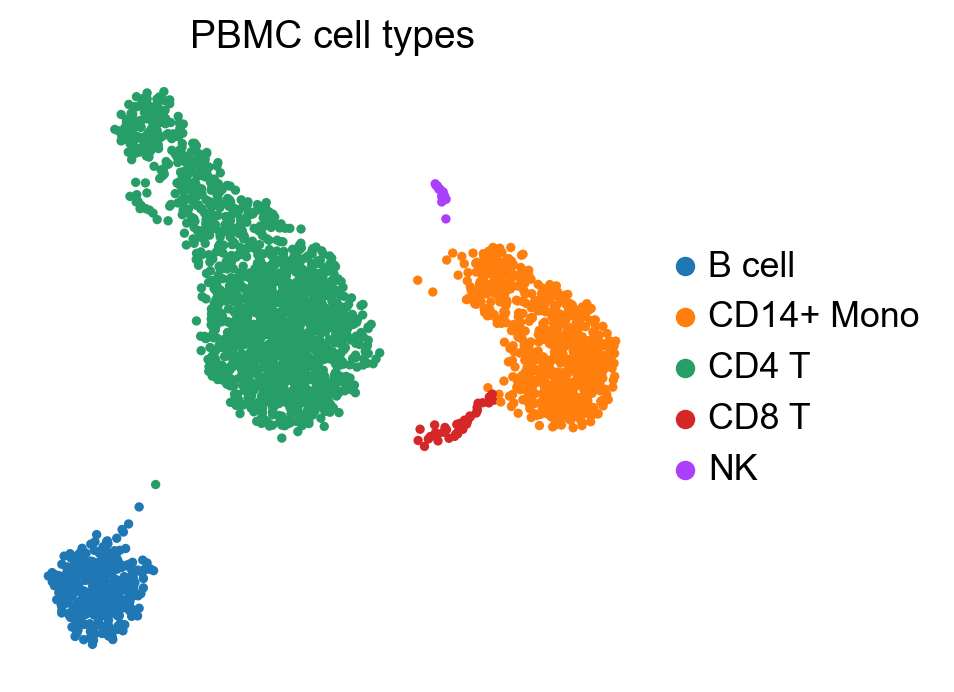

In [14]:
# Assign cell type labels to clusters based on marker inspection
# Adjust this mapping after reviewing the dotplot above
cluster_labels = {
    '0': 'CD4 T',
    '1': 'CD14+ Mono',
    '2': 'CD4 T',
    '3': 'B cell',
    '4': 'CD8 T',
    '5': 'NK',
    '6': 'FCGR3A+ Mono',
    '7': 'Dendritic',
    '8': 'Platelet',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_labels).astype('category')

sc.pl.umap(
    adata, color='cell_type',
    legend_loc='right margin',
    title='PBMC cell types',
    frameon=False
)

## 8. Differential Expression

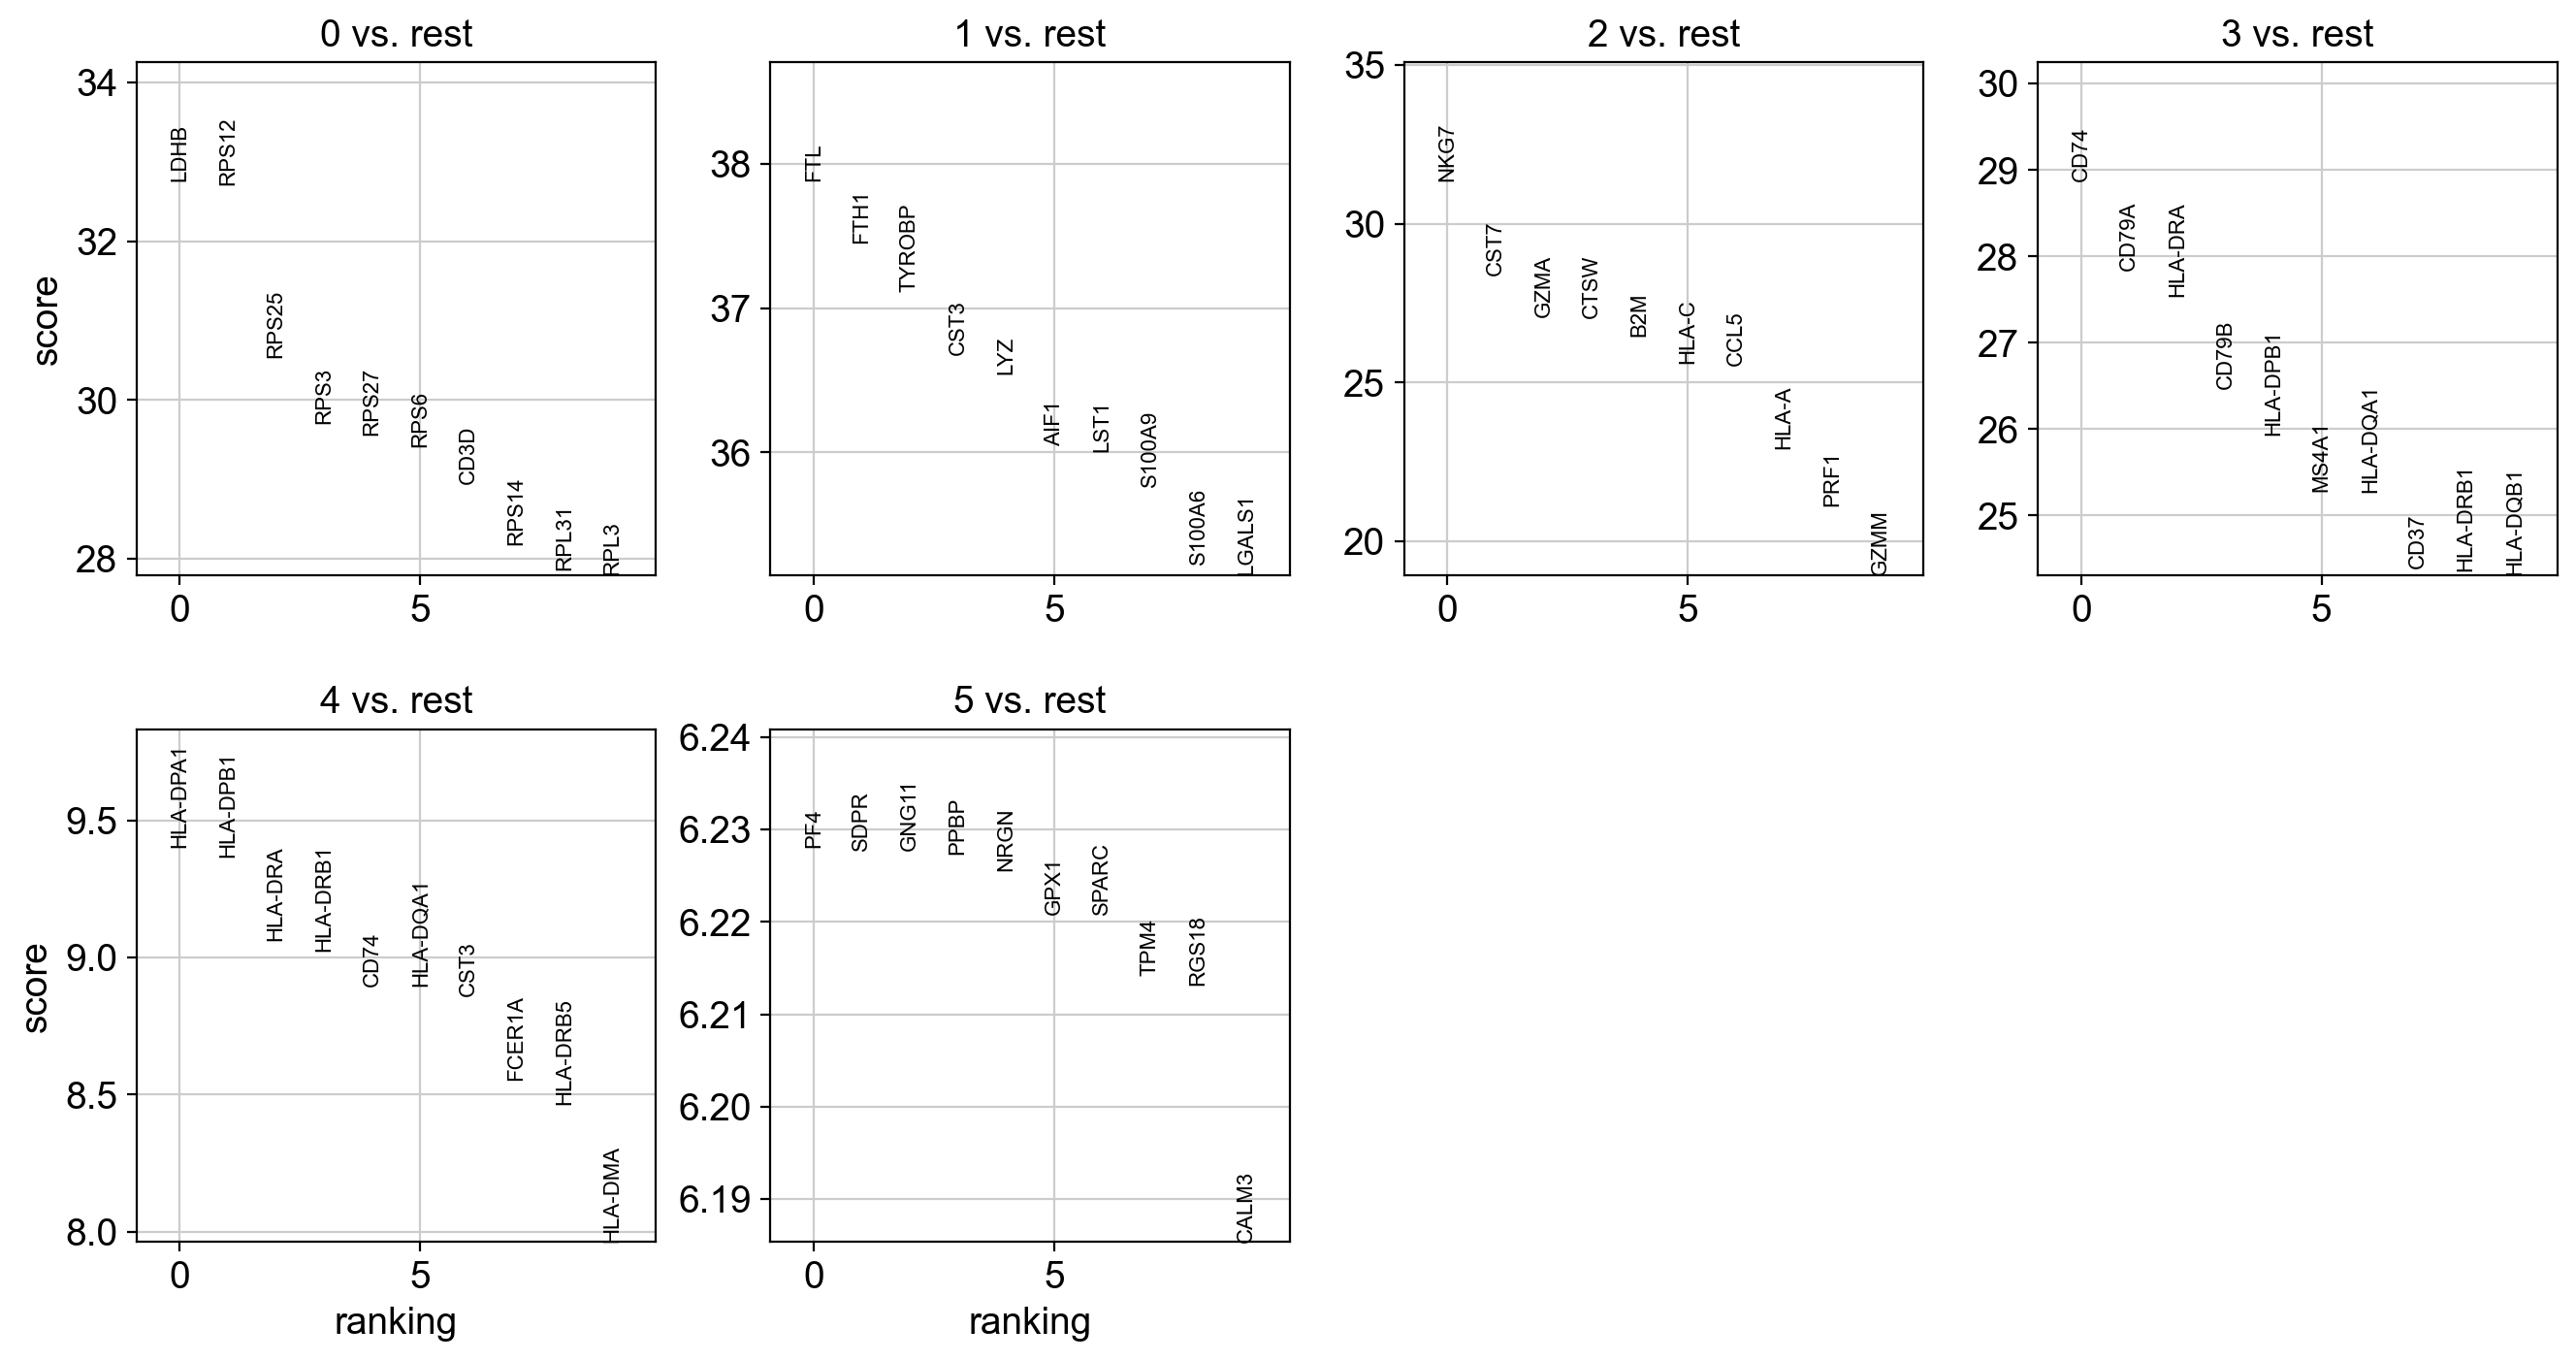

In [15]:
# Find marker genes for each cluster vs all others (Wilcoxon rank-sum)
sc.tl.rank_genes_groups(
    adata,
    groupby='leiden',
    method='wilcoxon',
    use_raw=True,
    pts=True,          # fraction of cells expressing each gene
)

sc.pl.rank_genes_groups(adata, n_genes=10, sharey=False)

In [16]:
# View top DE genes as a table
de_results = sc.get.rank_genes_groups_df(adata, group=None)
de_results.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,0,LDHB,32.760845,2.780137,2.127754e-235,2.918002e-231,0.922629,0.467967
1,0,RPS12,32.704769,1.065496,1.335969e-234,9.160740e-231,1.000000,0.988162
2,0,RPS25,30.536123,1.181895,8.642850e-205,2.370561e-201,0.998336,0.966574
3,0,RPS3,29.702429,0.895419,7.143746e-194,1.224617e-190,1.000000,0.992340
4,0,RPS27,29.557611,1.031681,5.242999e-192,7.989166e-189,0.999168,0.988858
5,0,RPS6,29.414000,0.879285,3.636724e-190,4.987403e-187,1.000000,0.993036
6,0,CD3D,28.943104,3.363375,3.427056e-184,4.272604e-181,0.872712,0.224930
7,0,RPS14,28.177158,0.779796,1.114156e-174,1.091395e-171,1.000000,0.992340
8,0,RPL31,27.852339,1.143404,1.009103e-170,9.225897e-168,0.998336,0.950557
9,0,RPL3,27.790260,0.874252,5.688331e-170,4.875611e-167,0.998336,0.993733


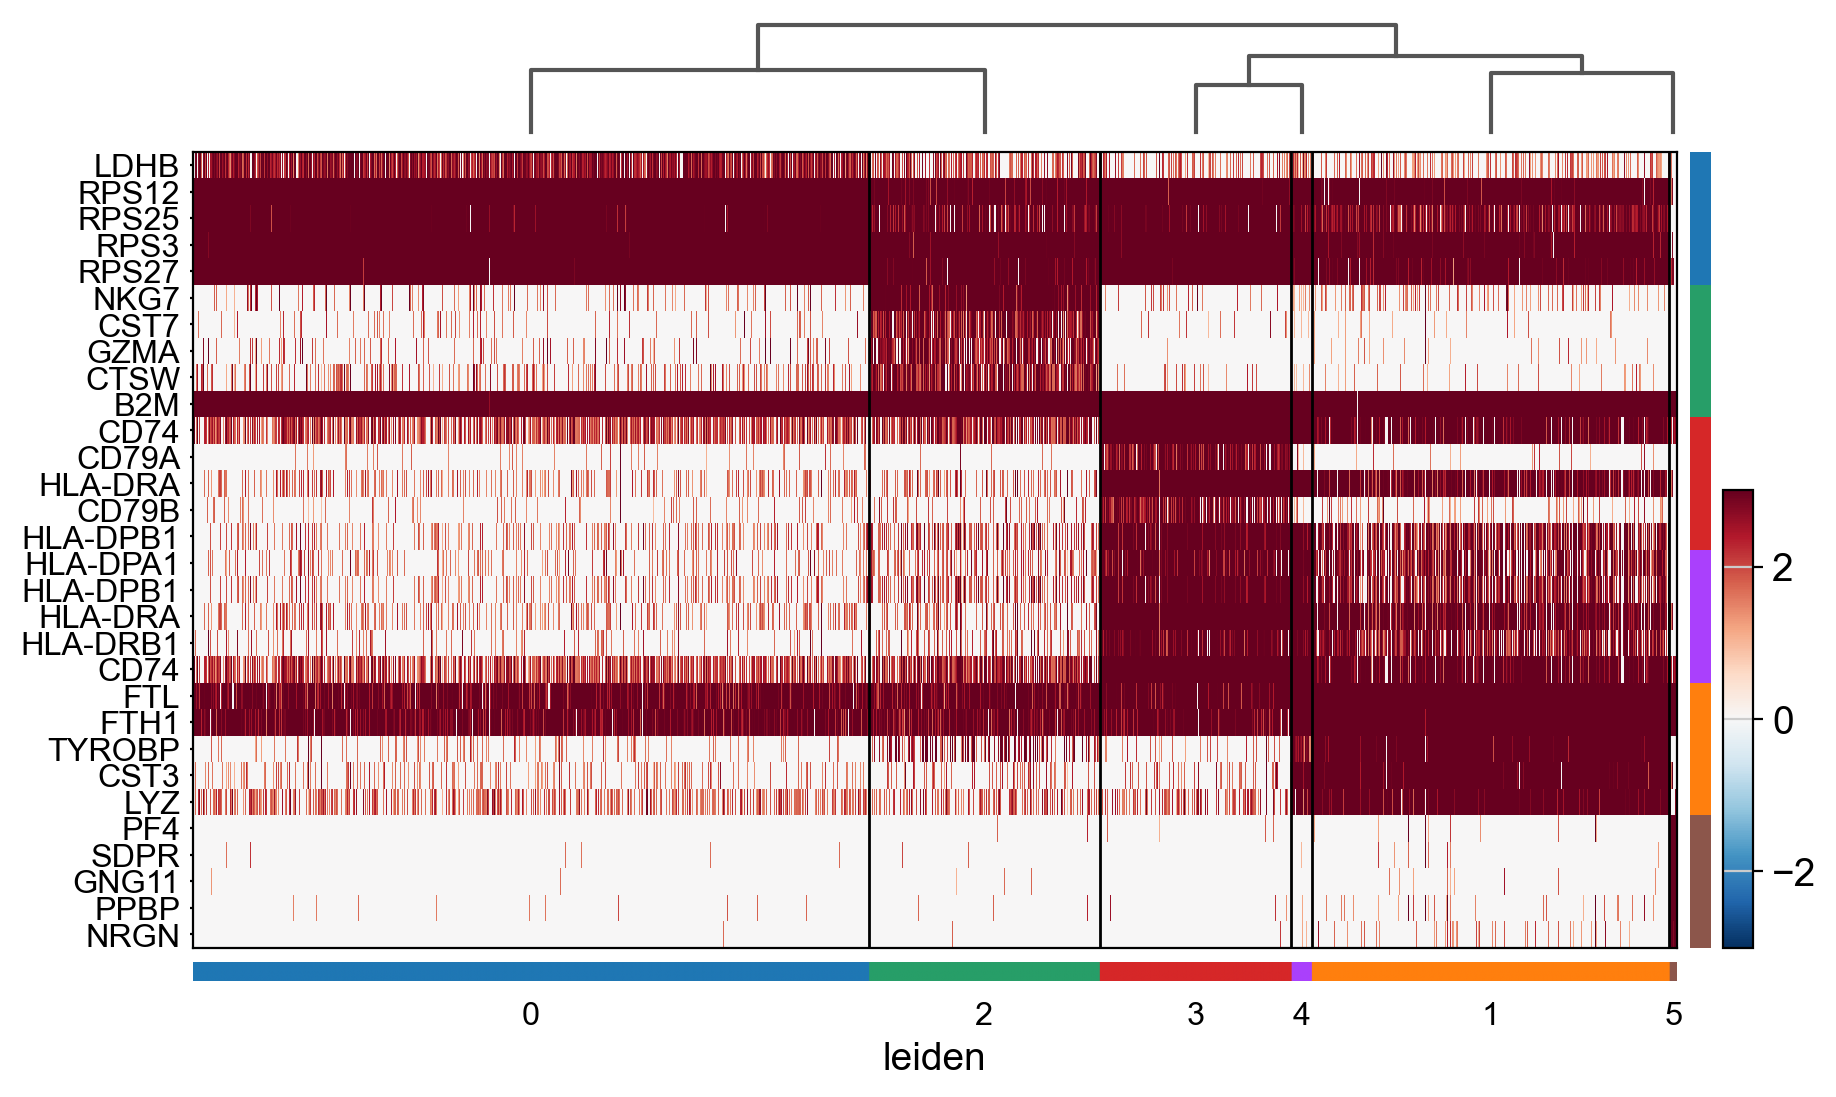

In [17]:
# Heatmap of top 5 marker genes per cluster
sc.pl.rank_genes_groups_heatmap(
    adata,
    n_genes=5,
    use_raw=True,
    swap_axes=True,
    show_gene_labels=True,
    vmin=-3, vmax=3,
    cmap='RdBu_r'
)

In [18]:
# Focused pairwise DE: CD4 T vs CD8 T
sc.tl.rank_genes_groups(
    adata,
    groupby='cell_type',
    groups=['CD4 T'],
    reference='CD8 T',
    method='wilcoxon',
    use_raw=True,
    key_added='de_cd4_vs_cd8'
)

cd4_vs_cd8 = sc.get.rank_genes_groups_df(adata, group='CD4 T', key='de_cd4_vs_cd8')
print('Top upregulated in CD4 T vs CD8 T:')
cd4_vs_cd8[cd4_vs_cd8.logfoldchanges > 0].head(10)

Top upregulated in CD4 T vs CD8 T:


,names,scores,logfoldchanges,pvals,pvals_adj
0,MALAT1,9.683855,1.634588,3.531434e-22,4.402735e-19
1,RPS27,8.338920,1.085387,7.497251e-17,3.808048e-14
2,RPS27A,8.243484,1.512825,1.672661e-16,8.192452e-14
3,RPL23A,8.088028,0.905059,6.063866e-16,2.598745e-13
4,RPL21,7.894857,1.111607,2.906485e-15,1.138844e-12
5,CD3D,7.857852,5.005100,3.907776e-15,1.488645e-12
6,B2M,7.751971,0.875926,9.047721e-15,3.181550e-12
7,IL32,7.740108,4.279347,9.933250e-15,3.405615e-12
8,BTG1,7.106770,1.570740,1.187902e-12,2.808773e-10
9,PTPRCAP,7.056663,3.292631,1.705492e-12,3.815925e-10


## 9. Save Results

In [19]:
adata.write_h5ad('pbmc3k_analyzed.h5ad')
de_results.to_csv('de_all_clusters.csv', index=False)
print('Saved pbmc3k_analyzed.h5ad and de_all_clusters.csv')

Saved pbmc3k_analyzed.h5ad and de_all_clusters.csv
